## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [13]:
df = pd.read_csv("Diwali Sales Data.csv", encoding="unicode_escape")

In [17]:
df.head(7)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.0,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.0,NaN,NaN


In [15]:
df.shape

(11251, 15)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [19]:
df.drop(["Status", "unnamed1"], axis=1, inplace=True)

In [20]:
df.shape

(11251, 13)

In [22]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [23]:
(12/len(df))*100

0.10665718602790863

In [24]:
df.dropna(inplace=True)

In [26]:
df.shape

(11239, 13)

In [28]:
df['Amount'] = df['Amount'].astype('int64')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  object
 2   Product_ID        11239 non-null  object
 3   Gender            11239 non-null  object
 4   Age Group         11239 non-null  object
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  object
 8   Zone              11239 non-null  object
 9   Occupation        11239 non-null  object
 10  Product_Category  11239 non-null  object
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [33]:
df.rename(columns={"Marital_Status": "Marriage_Status"}, inplace=True)

In [109]:
df.replace([0, 1], ['Unmarried', 'Married'], inplace=True)

In [110]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marriage_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Unmarried,Maharashtra,Western,Healthcare,Auto,Married,23952
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,Unmarried,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,Unmarried,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,Unmarried,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,Unmarried,Karnataka,Southern,Agriculture,Office,3,206


In [111]:
df["Orders"].replace(["Married"], [1], inplace=True)

In [112]:
df[["Age", "Orders", "Amount"]].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


## Analysis

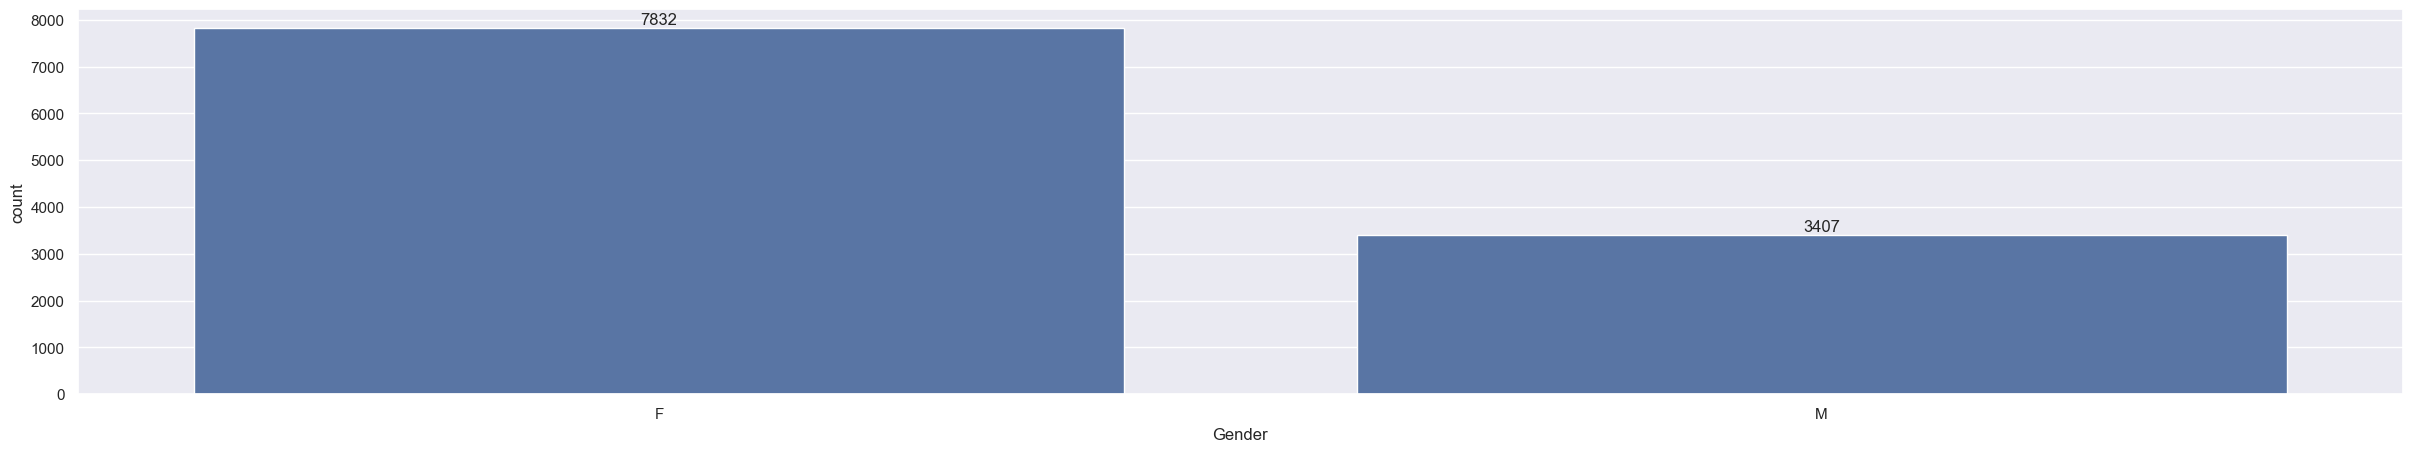

In [113]:
ax = sns.countplot(x="Gender", data=df)
for bars in ax.containers:
    ax.bar_label(bars)

In [114]:
gen_amt_df = df.groupby(['Gender'], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True)

<Axes: xlabel='Gender', ylabel='Amount'>

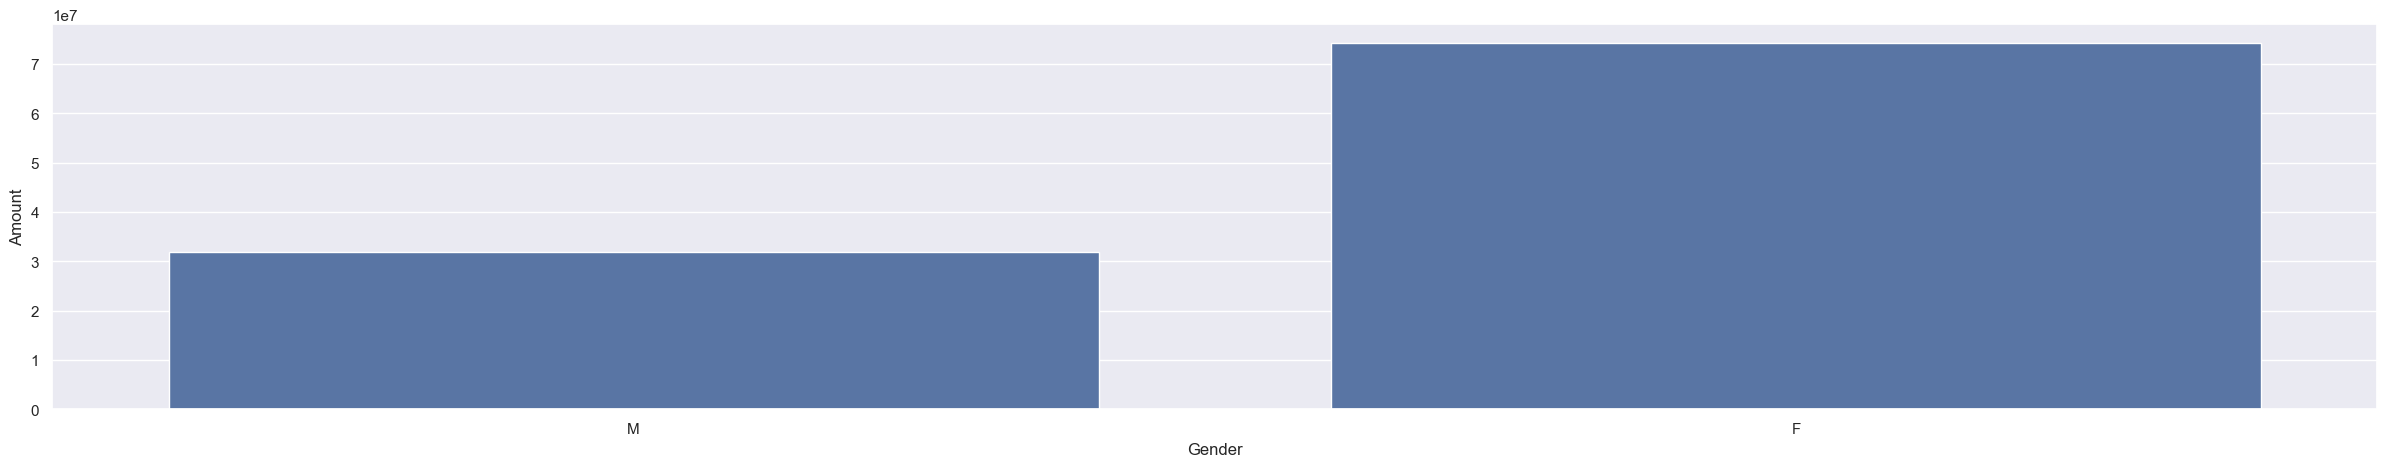

In [115]:
sns.barplot(x="Gender", y="Amount", data=gen_amt_df)

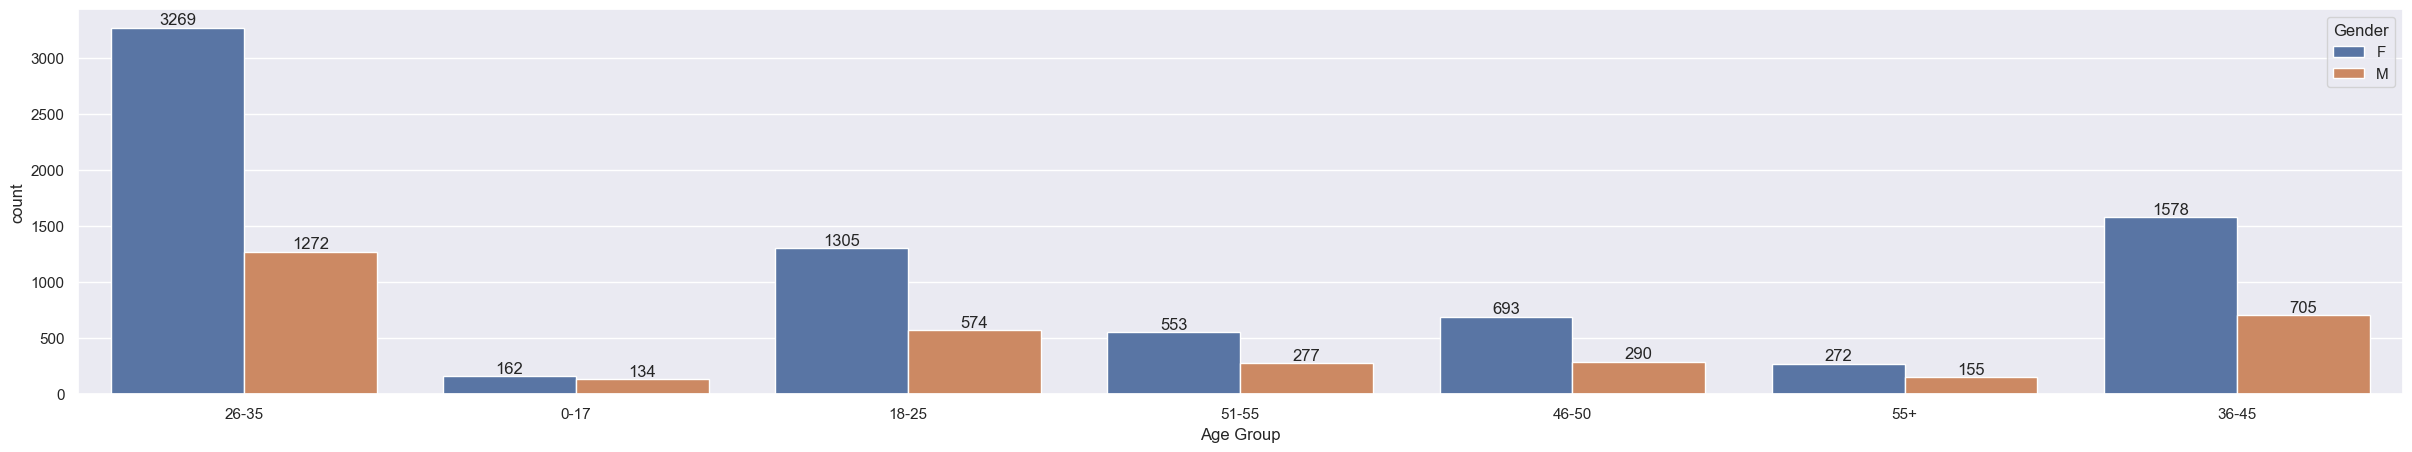

In [116]:
gen_age_group_df = sns.countplot(x="Age Group", data=df, hue="Gender")
for bars in gen_age_group_df.containers:
    gen_age_group_df.bar_label(bars)

In [117]:
age_group_amount_df = df.groupby(['Age Group'], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True)

<Axes: xlabel='Age Group', ylabel='Amount'>

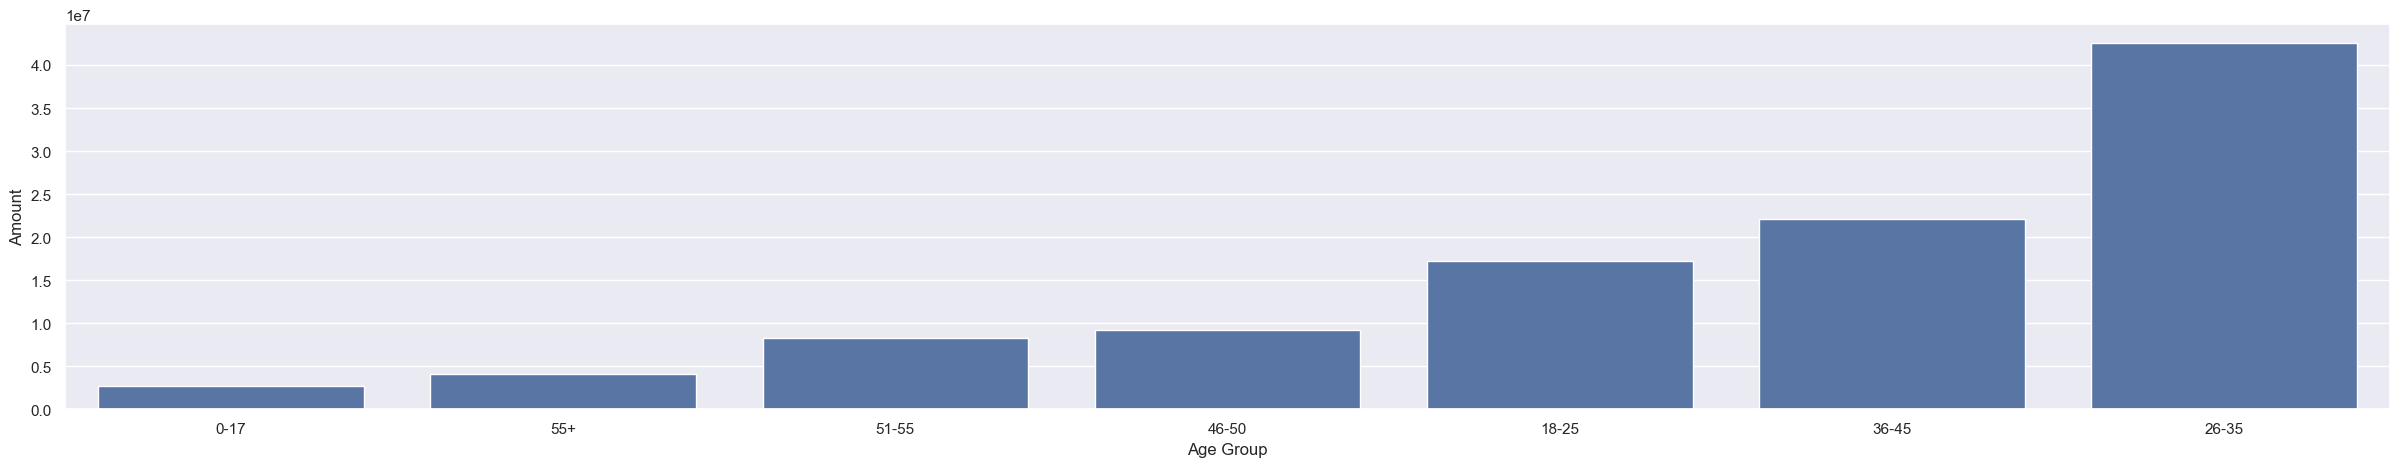

In [118]:
sns.barplot(x="Age Group", y="Amount", data=age_group_amount_df)

In [119]:
state_orders_df = df.groupby(["State"], as_index=False)["Orders"].sum().sort_values(by="Orders", ascending=True)

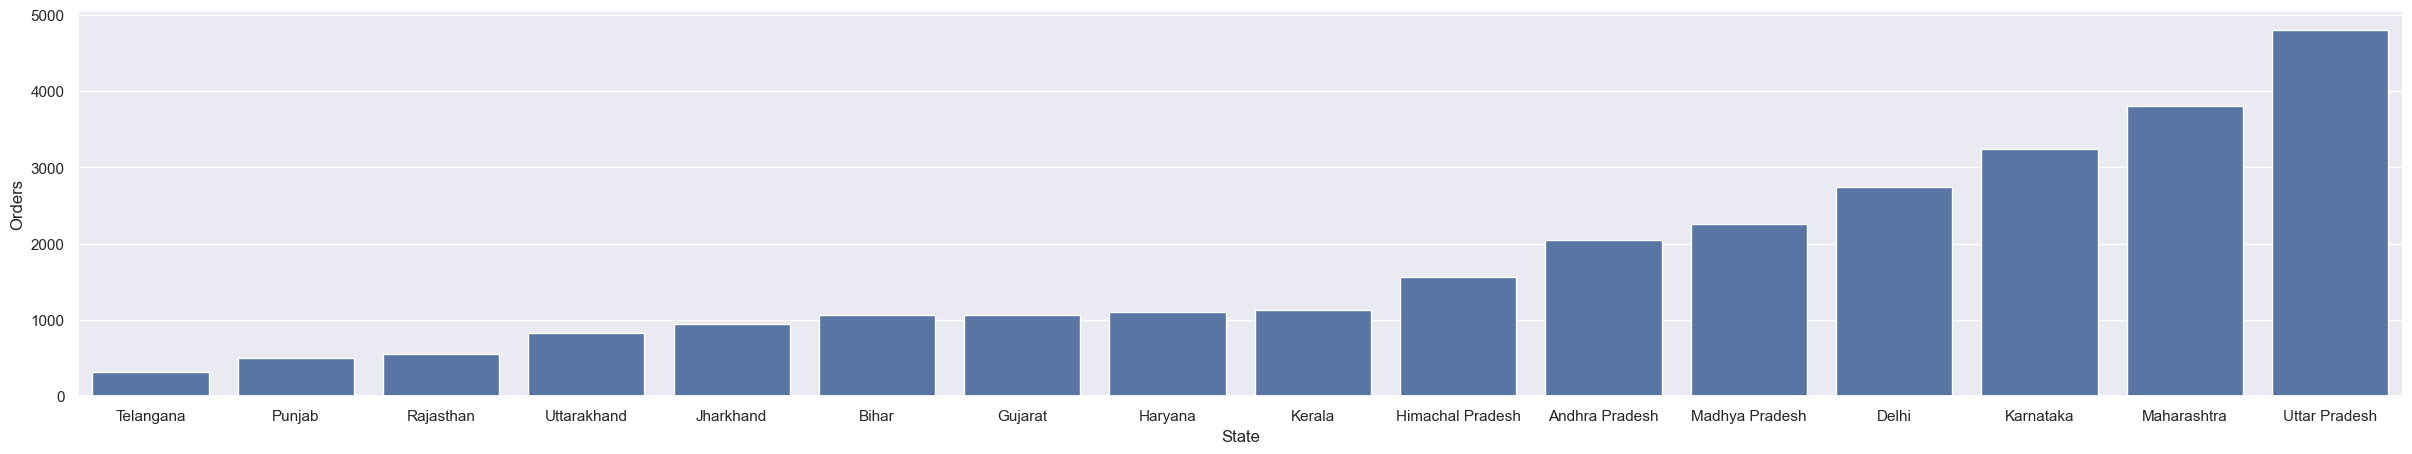

In [120]:
sns.barplot(x="State", y="Orders", data=state_orders_df)
sns.set(rc={"figure.figsize": (30, 5)})

In [121]:
state_amount_df = df.groupby(["State"], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True)

<Axes: xlabel='State', ylabel='Amount'>

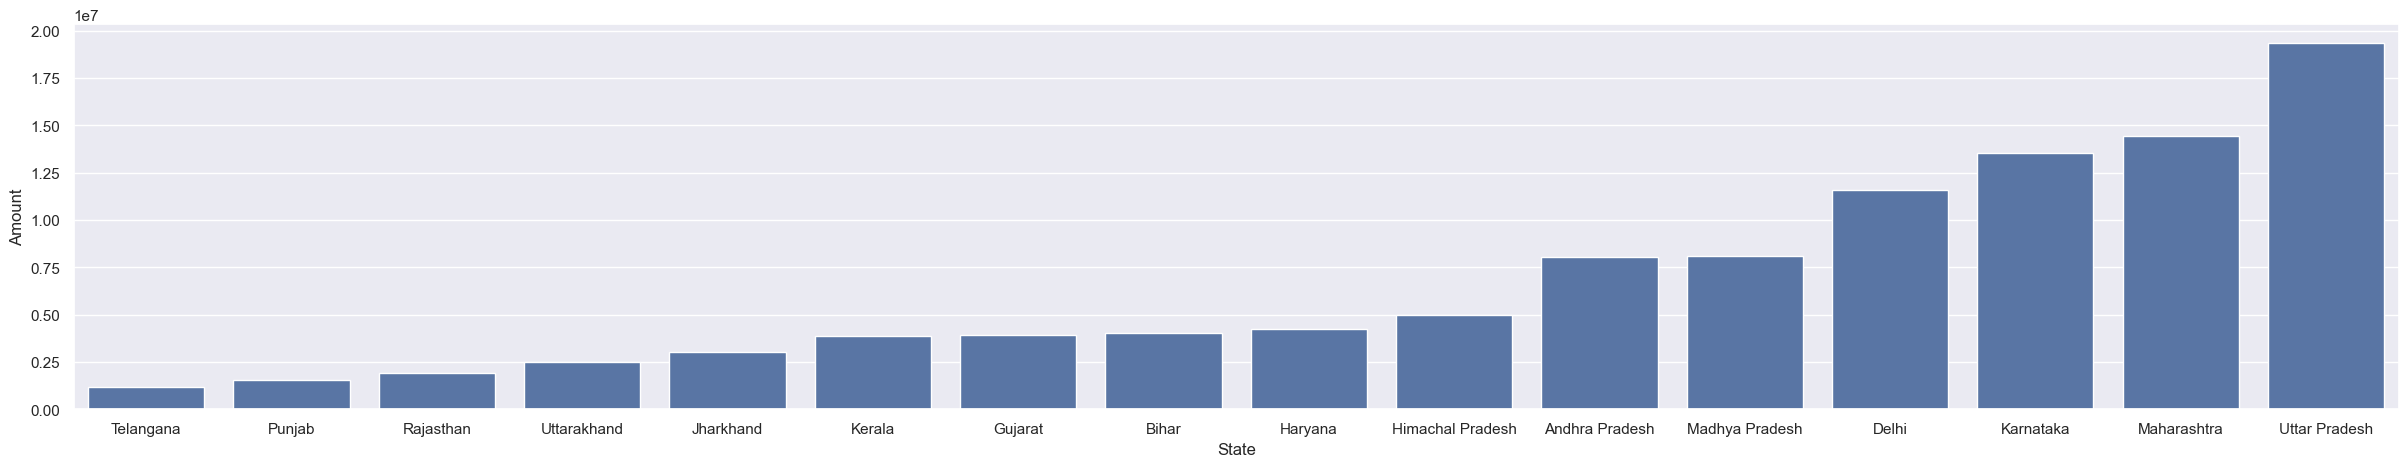

In [122]:
sns.barplot(x="State", y="Amount", data=state_amount_df)

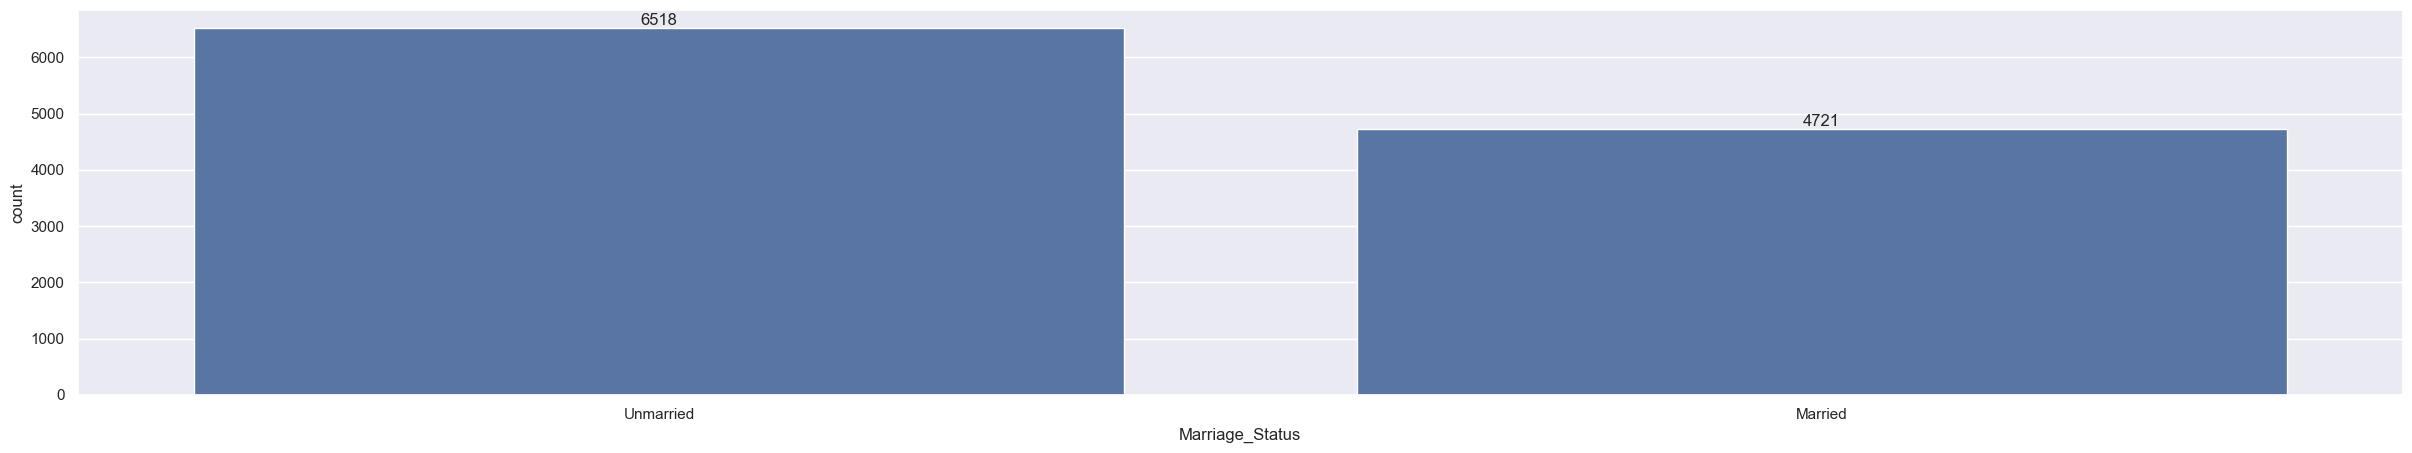

In [123]:
ax = sns.countplot(x="Marriage_Status", data=df)
for bars in ax.containers:
    ax.bar_label(bars)

In [139]:
age_group_gender_amount_df = df.groupby(['Marriage_Status', 'Gender'], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True)
age_group_gender_amount_df

,Marriage_Status,Gender,Amount
1,Married,M,13574538
3,Unmarried,M,18338738
0,Married,F,30549207
2,Unmarried,F,43786646


<Axes: xlabel='Marriage_Status', ylabel='Amount'>

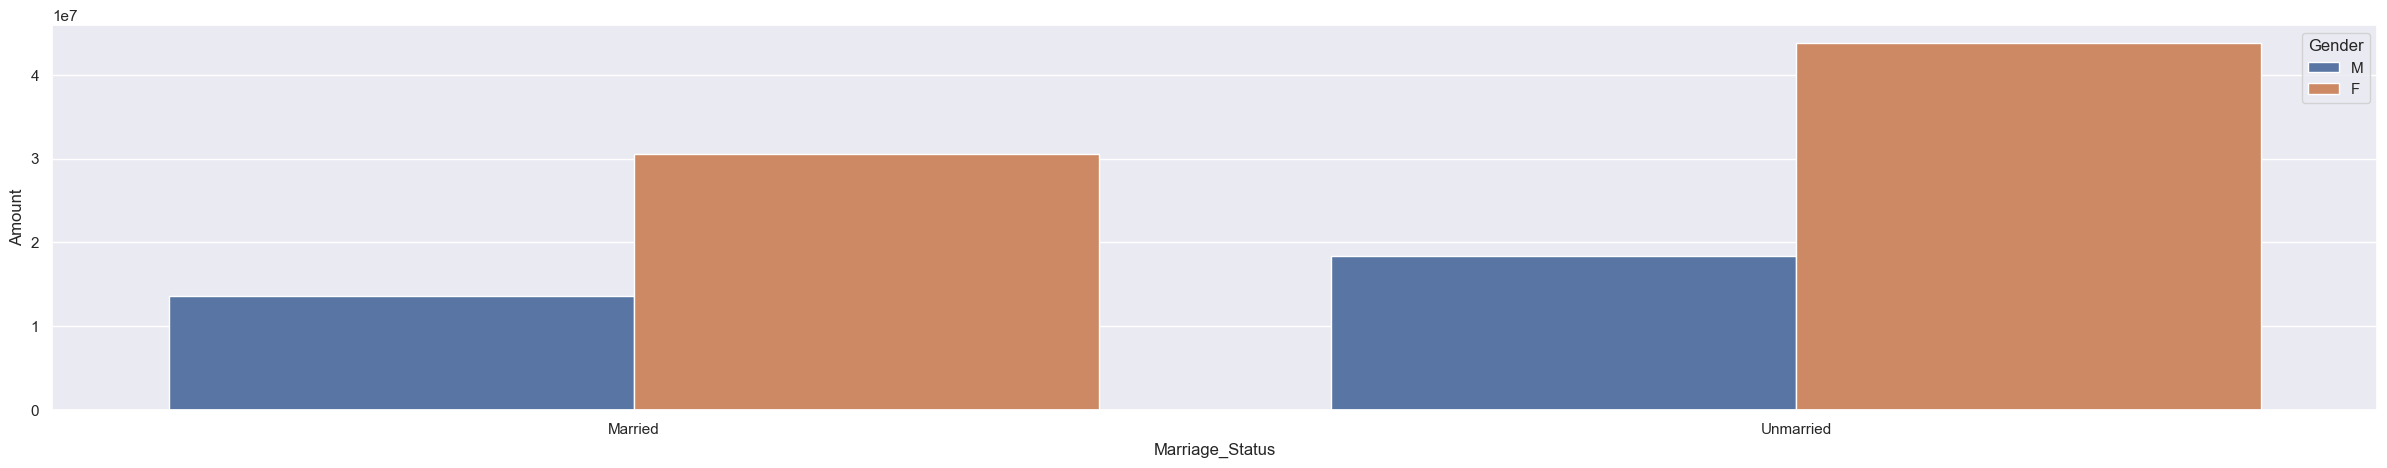

In [143]:
sns.barplot(data=age_group_gender_amount_df, x="Marriage_Status", y="Amount", hue="Gender")

In [146]:
occupation_amt_df = df.groupby(["Occupation"], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True)

<Axes: xlabel='Occupation', ylabel='Amount'>

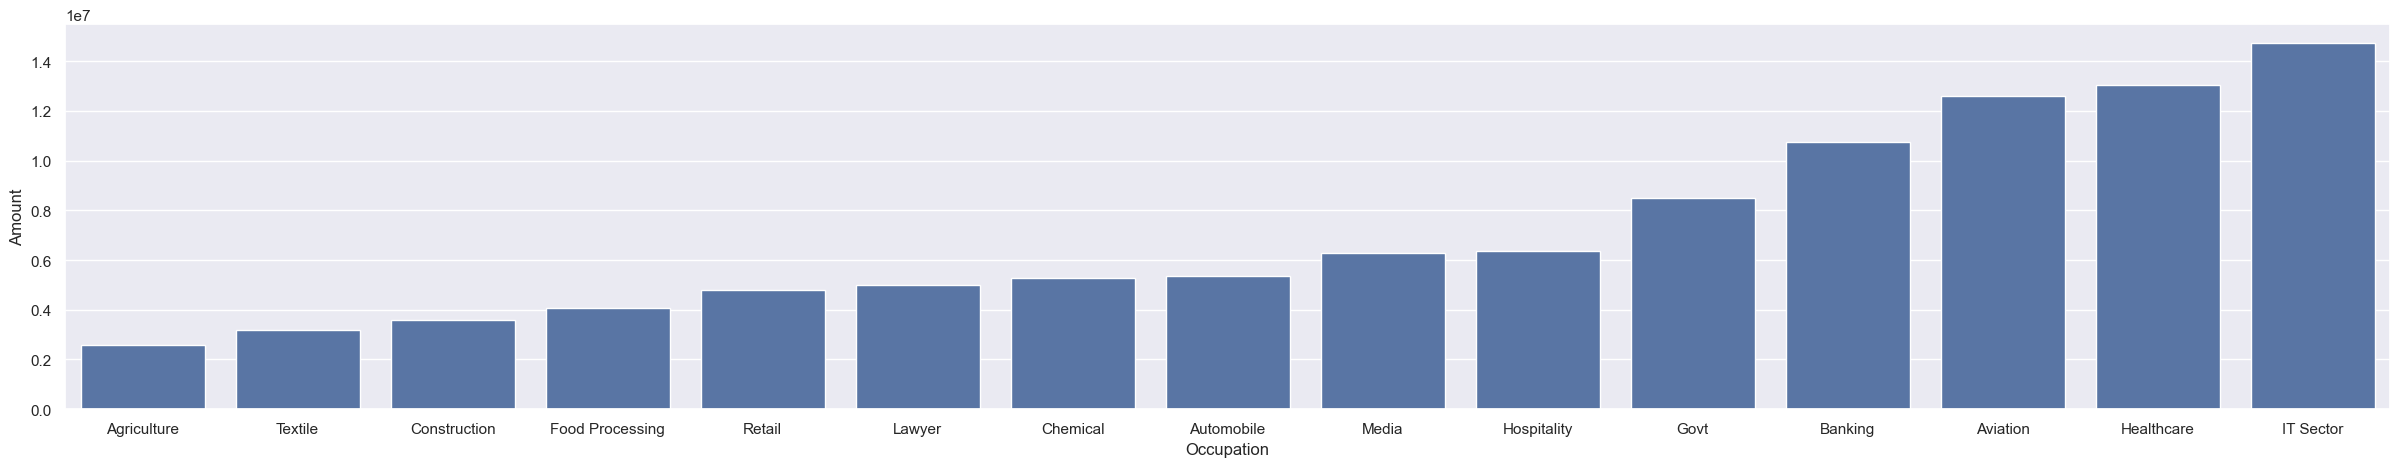

In [147]:
sns.barplot(x="Occupation", y="Amount", data=occupation_amt_df)

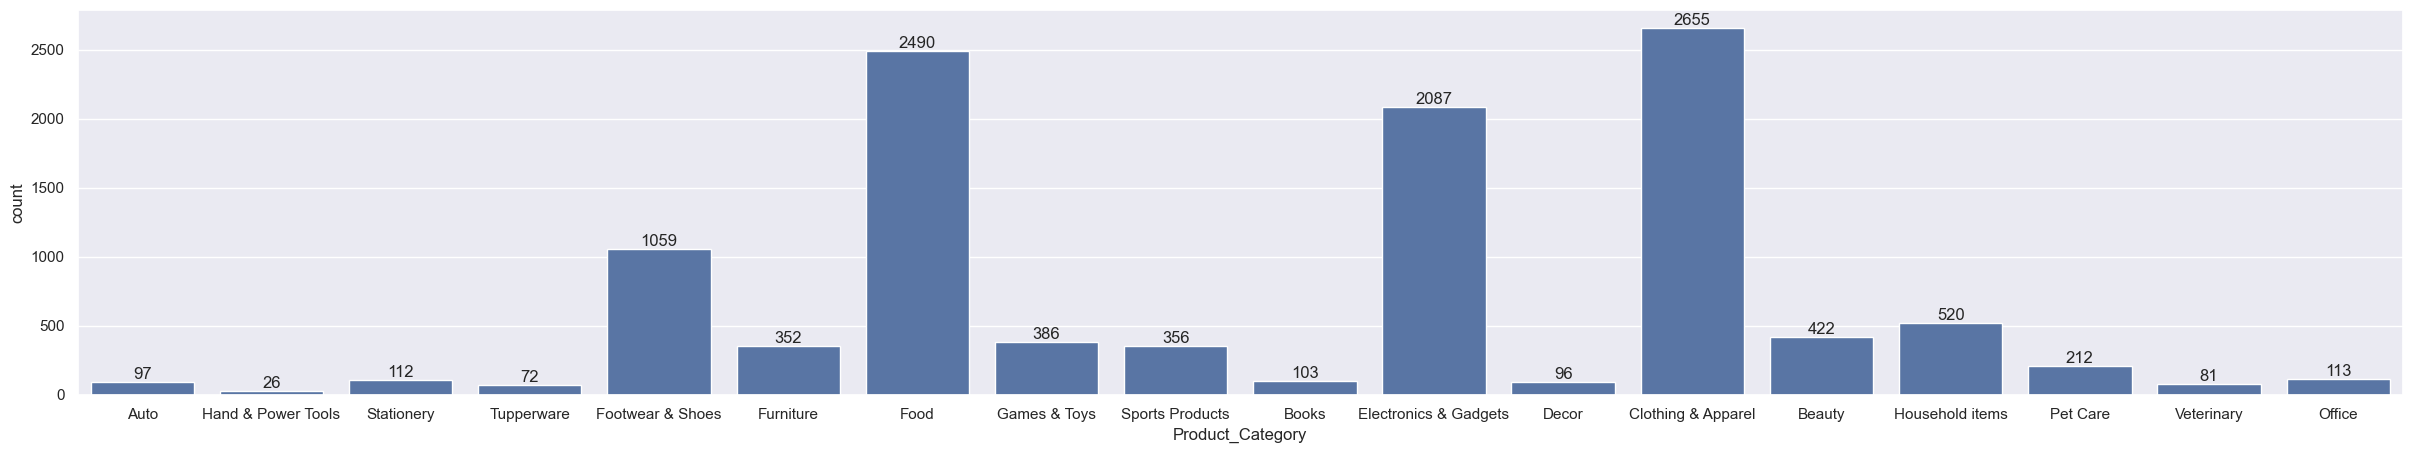

In [150]:
ax = sns.countplot(x="Product_Category", data=df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

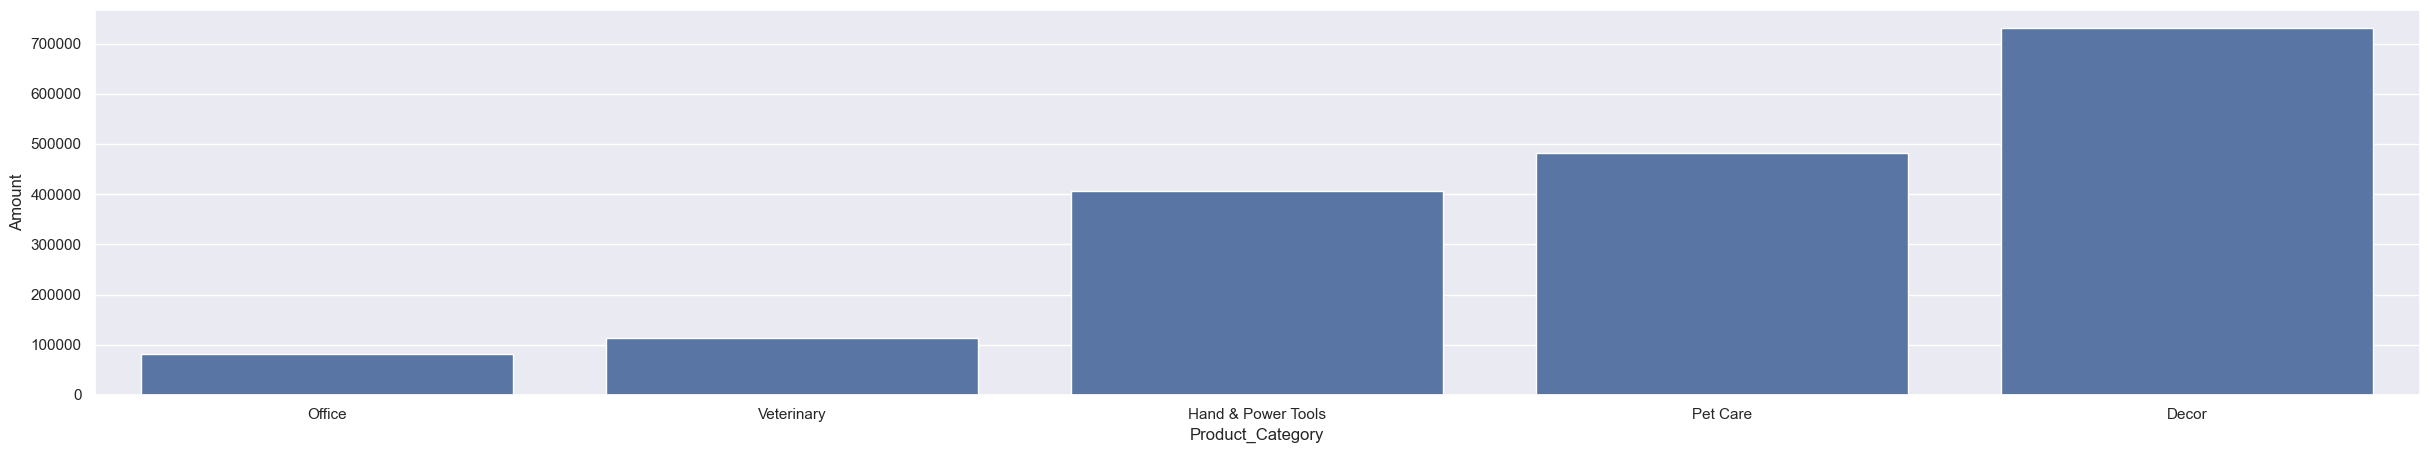

In [154]:
prod_cat_amt_df = df.groupby(["Product_Category"], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=True).head(5)
sns.barplot(x="Product_Category", y="Amount", data=prod_cat_amt_df)

<Axes: xlabel='Product_ID', ylabel='Amount'>

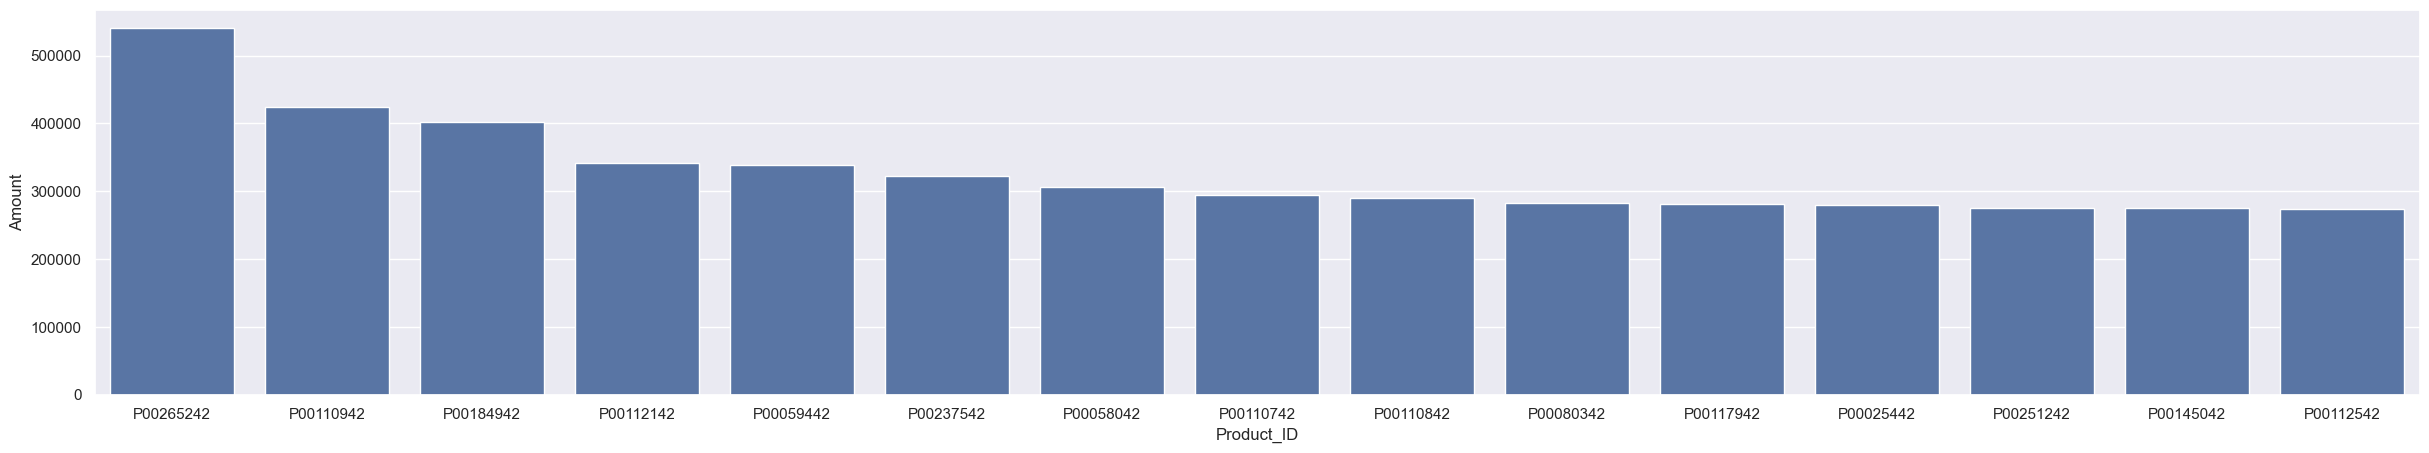

In [161]:
product_id_amt_df = df.groupby(["Product_ID"], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False).head(15)
sns.barplot(x="Product_ID", y="Amount", data=product_id_amt_df)